Linear Regression: Customer Lifetime Value.
Which customer characteristics are most predictive of Customer Lifetime Value, and how accurately can we estimate a customer's future LTV using behavioral and engagement data?

In [243]:
import pandas as pd 
import matplotlib.pyplot as plt

customer_data = pd.read_csv('ecommerce_customer_features.csv')

In [244]:
customer_data.head()

,Customer_ID,account_age_months,avg_order_value,total_orders,days_since_last_purchase,discount_usage_rate,return_rate,customer_support_tickets,loyalty_member,browsing_frequency_per_week,cart_abandonment_rate,product_review_score_avg,engagement_score,satisfaction_score,price_sensitivity_index
0,0520df14-712d-4c69-a0c5-95a2e7dfc1ff,46,164.96,12,17,0.243,0.1720,0,No,6.1,0.430,5.00,6.58,9.43,3.7
1,a4013b3f-0688-4096-a194-6074be8ffec8,3,39.09,4,5,0.591,0.0808,1,No,4.1,0.183,4.44,6.25,8.50,6.9
2,eb870f2c-ed3d-4a21-a8ac-273fae69ea4f,29,37.42,8,47,0.212,0.1424,0,No,1.2,0.426,3.87,3.32,8.40,4.3
3,a7433451-8ea9-428a-9d80-679c6963b39f,35,62.64,9,3,0.699,0.0128,0,No,3.8,0.730,4.75,6.42,9.71,7.5
4,43f81935-49e3-44d3-94d1-5c4715738988,39,113.03,1,7,0.382,0.0232,0,No,5.4,0.613,5.00,6.48,9.92,5.0


EDA: Check for null or missing values, 1. Customer LTV[avg_order_value * total_orders] descriptive stats(mean, median, distribution), 2. Customer lifespan(account_age mean and median), 3. LTV across groups(loyalty_member, browsing_freq, price_sensitivity), 4. variables strongly correlated with LTV, and 5. characteristics of customers with high LTV.

In [245]:
customer_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 15 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Customer_ID                  6000 non-null   object 
 1   account_age_months           6000 non-null   int64  
 2   avg_order_value              6000 non-null   float64
 3   total_orders                 6000 non-null   int64  
 4   days_since_last_purchase     6000 non-null   int64  
 5   discount_usage_rate          6000 non-null   float64
 6   return_rate                  6000 non-null   float64
 7   customer_support_tickets     6000 non-null   int64  
 8   loyalty_member               6000 non-null   object 
 9   browsing_frequency_per_week  6000 non-null   float64
 10  cart_abandonment_rate        6000 non-null   float64
 11  product_review_score_avg     6000 non-null   float64
 12  engagement_score             6000 non-null   float64
 13  satisfaction_score

In [246]:
customer_data.duplicated().value_counts()

False    6000
Name: count, dtype: int64

KPI 1: Calculate and create lifetime value(LTV) column

In [247]:
customer_data['ltv'] = customer_data['avg_order_value'] * customer_data['total_orders']

In [248]:
ltv = customer_data['ltv']
ltv.describe()

count     6000.000000
mean       703.658552
std       1088.853740
min         10.000000
25%         79.370000
50%        274.460000
75%        906.705000
max      15534.260000
Name: ltv, dtype: float64

LTV Mean: 703.66 Median: 274.46

Customer LTV distribution

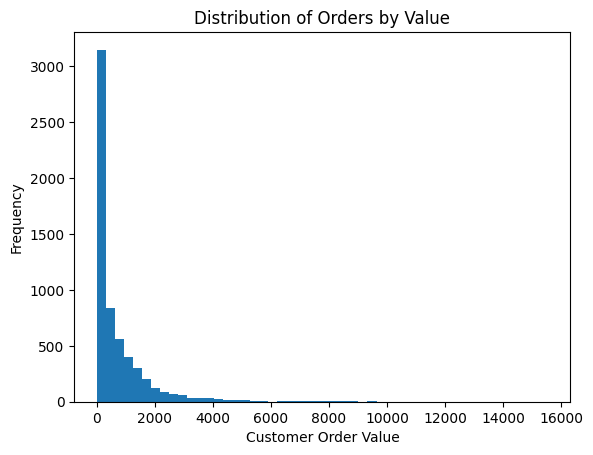

In [249]:
plt.hist(ltv, bins = 50)
plt.xlabel('Customer Order Value')
plt.ylabel('Frequency')
plt.title('Distribution of Orders by Value')
plt.show()

KPI 2: Average Customer Lifespan

In [250]:
customer_data['account_age_months'].describe()

count    6000.000000
mean       30.806667
std        17.358115
min         1.000000
25%        16.000000
50%        31.000000
75%        46.000000
max        60.000000
Name: account_age_months, dtype: float64

Mean: 30.8
Median: 31

KPI 3: LTV across customer groups(loyalty_member, browser_frequency)

In [251]:
customer_data.groupby('loyalty_member')['ltv'].mean()

loyalty_member
No      583.224905
Yes    1249.217419
Name: ltv, dtype: float64

Loyalty member LTV is on average more the 2x greater than non-members

Browser frequency segmentation and LTV

In [252]:
customer_data['browsing_frequency_per_week'].describe()

count    6000.000000
mean        3.076683
std         1.893899
min         0.000000
25%         1.600000
50%         3.000000
75%         4.400000
max        10.300000
Name: browsing_frequency_per_week, dtype: float64

In [253]:
customer_data['browsing_segment'] = pd.qcut(
    customer_data['browsing_frequency_per_week'],
    q = 3,
    labels = ['Low', 'Medium','High'],
)

In [254]:
customer_data.groupby('browsing_segment')['ltv'].mean()

C:\Users\Arian\AppData\Local\Temp\ipykernel_3112\2010798881.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  customer_data.groupby('browsing_segment')['ltv'].mean()


browsing_segment
Low       711.646519
Medium    723.421395
High      675.237268
Name: ltv, dtype: float64

KPI 4: Variables most strongly correlated with LTV

In [255]:
cus_df = customer_data.drop(columns='Customer_ID')

cus_df['loyalty_member'] = cus_df['loyalty_member'].replace({
    'No':0,
    'Yes':1
})
correlation_matrix = cus_df.corr(numeric_only=True)

C:\Users\Arian\AppData\Local\Temp\ipykernel_3112\17761737.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  cus_df['loyalty_member'] = cus_df['loyalty_member'].replace({


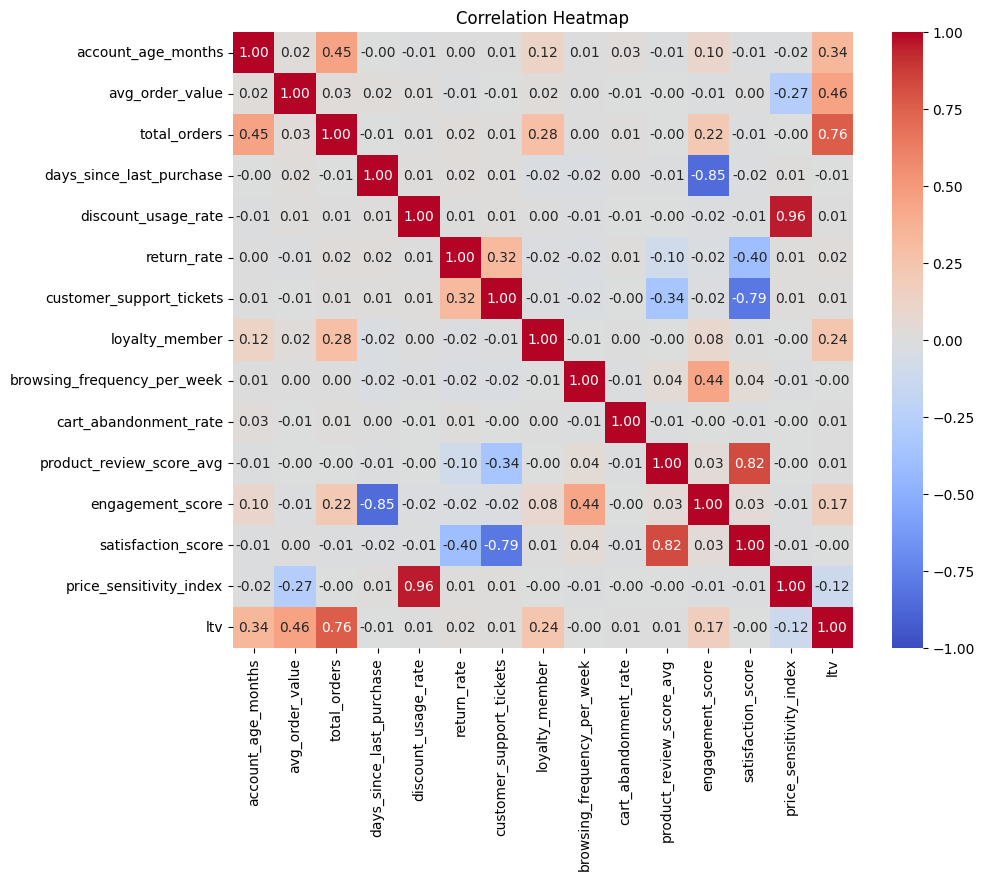

In [256]:
import seaborn as sns
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

KPI 5: What characteristics define high-value customers?(Top 10%)

In [257]:
customer_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 17 columns):
 #   Column                       Non-Null Count  Dtype   
---  ------                       --------------  -----   
 0   Customer_ID                  6000 non-null   object  
 1   account_age_months           6000 non-null   int64   
 2   avg_order_value              6000 non-null   float64 
 3   total_orders                 6000 non-null   int64   
 4   days_since_last_purchase     6000 non-null   int64   
 5   discount_usage_rate          6000 non-null   float64 
 6   return_rate                  6000 non-null   float64 
 7   customer_support_tickets     6000 non-null   int64   
 8   loyalty_member               6000 non-null   object  
 9   browsing_frequency_per_week  6000 non-null   float64 
 10  cart_abandonment_rate        6000 non-null   float64 
 11  product_review_score_avg     6000 non-null   float64 
 12  engagement_score             6000 non-null   float64 
 13  sat

Behavioral characteristics: columns[5:] except ltv[15], product review avg[11], browsing_freq per week[9]

In [258]:
top_10_pct_threshold = customer_data['ltv'].quantile(0.90)
high_value_customers = customer_data[customer_data['ltv'] >= top_10_pct_threshold]

behavior_cols = [
    'account_age_months',
    'total_orders',
    'avg_order_value',
    'days_since_last_purchase',
    'discount_usage_rate',
    'return_rate',
    'customer_support_tickets',
    'browsing_frequency_per_week',
    'cart_abandonment_rate',
    'product_review_score_avg',
    'engagement_score',
    'satisfaction_score',
    'price_sensitivity_index'
]

high_value_behavior_summary = high_value_customers[behavior_cols].describe().T
high_value_behavior_means = high_value_customers[behavior_cols].mean()
overall_behavior_means = customer_data[behavior_cols].mean()

comparison = pd.DataFrame({
    'overall_mean': overall_behavior_means,
    'top_10pct_mean': high_value_behavior_means,
    'difference': high_value_behavior_means - overall_behavior_means
})

print(f"Top 10% LTV threshold: {top_10_pct_threshold:.2f}")
print(f"High-value customer count: {len(high_value_customers)}")
display(high_value_behavior_summary)
display(comparison)

Top 10% LTV threshold: 1755.62
High-value customer count: 600


,count,mean,std,min,25%,50%,75%,max
account_age_months,600.0,44.936667,11.124999,8.000,37.7500,47.0000,54.00000,60.0000
total_orders,600.0,26.485000,12.340864,5.000,16.0000,26.0000,32.25000,85.0000
avg_order_value,600.0,139.991917,81.425144,40.970,88.2750,123.6300,163.64000,1006.5300
days_since_last_purchase,600.0,30.461667,31.274836,0.000,9.0000,20.0000,42.00000,221.0000
discount_usage_rate,600.0,0.281150,0.148096,0.006,0.1740,0.2615,0.37225,0.7400
return_rate,600.0,0.072844,0.070165,0.000,0.0208,0.0488,0.10120,0.4104
customer_support_tickets,600.0,0.886667,1.035508,0.000,0.0000,1.0000,1.00000,6.0000
browsing_frequency_per_week,600.0,3.040167,1.871740,0.000,1.6000,3.0000,4.30000,8.7000
cart_abandonment_rate,600.0,0.607052,0.198399,0.093,0.4570,0.6170,0.76425,0.9830
product_review_score_avg,600.0,3.886400,0.769677,1.120,3.4075,3.9200,4.50000,5.0000


,overall_mean,top_10pct_mean,difference
account_age_months,30.806667,44.936667,14.130000
total_orders,8.567500,26.485000,17.917500
avg_order_value,80.487945,139.991917,59.503972
days_since_last_purchase,29.598167,30.461667,0.863500
discount_usage_rate,0.285057,0.281150,-0.003907
return_rate,0.071519,0.072844,0.001325
customer_support_tickets,0.857667,0.886667,0.029000
browsing_frequency_per_week,3.076683,3.040167,-0.036517
cart_abandonment_rate,0.602106,0.607052,0.004945
product_review_score_avg,3.879603,3.886400,0.006797


EDA Summary and Findings: 

Customer Lifetime Value (LTV) exhibits a heavily right-skewed distribution, indicating that a small group of customers generates a disproportionately large share of revenue. The average customer lifespan is approximately 31 months, suggesting a relatively stable customer tenure distribution. LTV is most strongly correlated with total orders (r = 0.76), followed by average order value (r = 0.46) and account age (r = 0.34). Loyalty program members generate higher LTV on average than non-members, indicating that loyalty initiatives may contribute to customer value. Customers in the top 10% of LTV have significantly longer average account tenures (44.9 vs. 30.8 months), place substantially more orders (26.5 vs. 8.6 orders), and spend more per order ($140 vs. $80) than other customers. High-value customers also exhibit higher engagement scores and lower price sensitivity, suggesting that customer retention and engagement are important drivers of long-term value. These findings indicate that strategies focused on increasing customer retention, purchase frequency, and loyalty program participation may have the greatest impact on revenue growth.

Model Visualizations

In [259]:
import linregmod
import importlib

importlib.reload(linregmod)
from linregmod import train_model1, train_model2
model1, X_test1, y_test1, predictions1, metrics1 = train_model1(customer_data)

model2, X_test2, y_test2, predictions2, metrics2 = train_model2(customer_data)

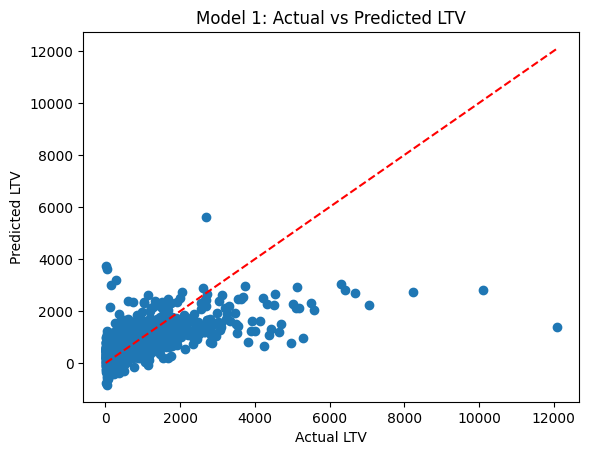

In [260]:
plt.scatter(y_test1, predictions1)

plt.plot(
    [y_test1.min(), y_test1.max()],
    [y_test1.min(), y_test1.max()],
    'r--'
)

plt.xlabel('Actual LTV')
plt.ylabel('Predicted LTV')
plt.title('Model 1: Actual vs Predicted LTV')

plt.show()

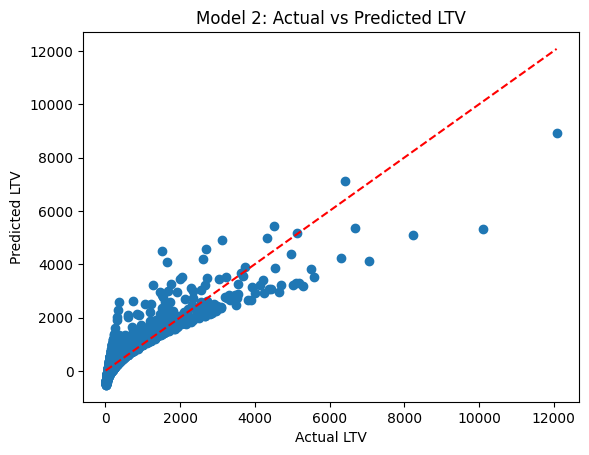

In [261]:
plt.scatter(y_test2, predictions2)

plt.plot(
    [y_test2.min(), y_test2.max()],
    [y_test2.min(), y_test2.max()],
    'r--'
)

plt.xlabel('Actual LTV')
plt.ylabel('Predicted LTV')
plt.title('Model 2: Actual vs Predicted LTV')

plt.show()

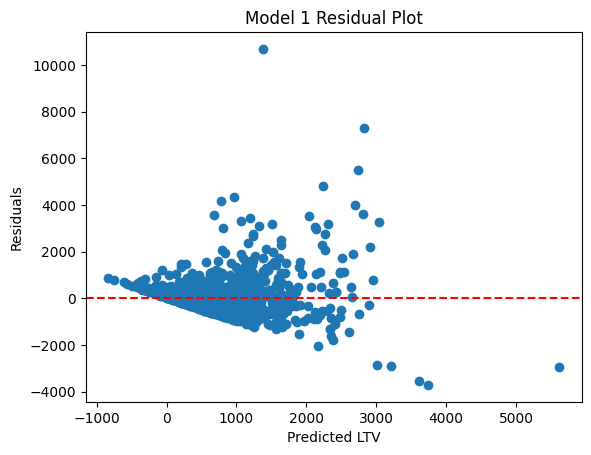

In [262]:
residuals1 = y_test1 - predictions1

plt.scatter(
    predictions1,
    residuals1
)

plt.axhline(
    y=0,
    color='red',
    linestyle='--'
)

plt.xlabel('Predicted LTV')
plt.ylabel('Residuals')
plt.title('Model 1 Residual Plot')

plt.show()

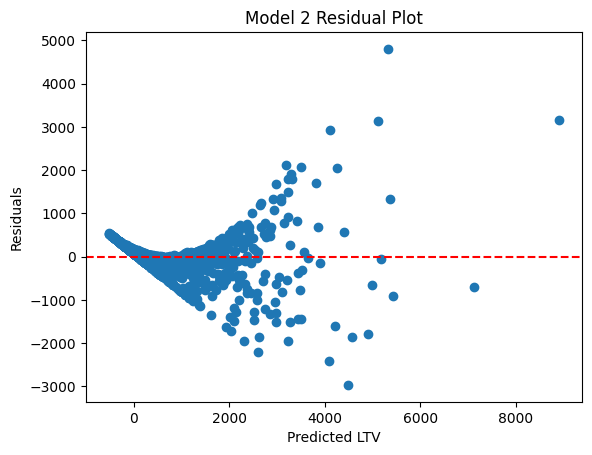

In [263]:
residuals2 = y_test2 - predictions2

plt.scatter(
    predictions2,
    residuals2
)

plt.axhline(
    y=0,
    color='red',
    linestyle='--'
)

plt.xlabel('Predicted LTV')
plt.ylabel('Residuals')
plt.title('Model 2 Residual Plot')

plt.show()